<a href="https://colab.research.google.com/github/diemacedo12/lis4693-lis5693/blob/main/lab-5/lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing and importing packages



In [40]:
!pip install gensim
!pip install pyldavis
!pip install nltk

In [41]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [42]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import pandas as pd
from nltk.corpus import stopwords
import string
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

Loading data




In [43]:
import requests
import io

url = "https://raw.githubusercontent.com/diemacedo12/lis4693-lis5693/refs/heads/main/lab-5/lens-export.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

Saving data as a DataFrame using df variable



In [44]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.head())

               Lens ID                                              Title  \
0  000-122-744-113-792  Editor's Note: EGFR Activation and Signaling i...   
1  000-935-967-706-286  1566P Clinical relevance of circulating tumor ...   
2  000-963-992-163-111  Regulating Tumorigenicity and Cancer Metastasi...   
3  000-965-490-020-750  Correction: Lysyl Oxidase-like Protein LOXL2 P...   
4  001-126-801-426-66X  ASO Author Reflections: Diagnosis and Treatmen...   

                                            Author/s  \
0  Alexandra Paye; Alice Truong; Cassandre Yip; J...   
1  H. Osumi; T. Wakatsuki; D. Takahari; A. Ooki; ...   
2  Yichao Fan; Boya Zhang; Xinhui Du; Bangmin Wan...   
3  Fernando Salvador; Alberto Martin; Celia López...   
4  Yunlong Li; Yingming Xiao; Zhengang Shen; Shen...   

                                            Abstract  
0                                      peer reviewed  
1                                                NaN  
2  Tropomyosin receptor kinase (TRK

In [45]:
df = df[["Title", "Author/s", "Abstract"]]
df

,Title,Author/s,Abstract
0,Editor's Note: EGFR Activation and Signaling i...,Alexandra Paye; Alice Truong; Cassandre Yip; J...,peer reviewed
1,1566P Clinical relevance of circulating tumor ...,H. Osumi; T. Wakatsuki; D. Takahari; A. Ooki; ...,NaN
2,Regulating Tumorigenicity and Cancer Metastasi...,Yichao Fan; Boya Zhang; Xinhui Du; Bangmin Wan...,"Tropomyosin receptor kinase (TRK) A, TRKA, is ..."
3,Correction: Lysyl Oxidase-like Protein LOXL2 P...,Fernando Salvador; Alberto Martin; Celia López...,"In the original version of this article (1), t..."
4,ASO Author Reflections: Diagnosis and Treatmen...,Yunlong Li; Yingming Xiao; Zhengang Shen; Shen...,NaN
...,...,...,...
995,Correction: Proliferation and AKT Activity Bio...,John F R Robertson; Robert E Coleman; Kwok-Leu...,"In the original version of this article (1), t..."
996,Head & Neck Oncology Track: Carotid Resection ...,Nicholas Bial; R. Bryan Bell; Allen Cheng; Ash...,NaN
997,Editor's Note: Deciphering the Mechanisms of T...,Zhe Chang; Zhongkui Li; Xiaoyang Wang; Ya'an K...,NaN
998,Defining concepts in cancer survivorship.,Michelle A Mollica; Michelle Doose; Crystal Re...,<jats:p>The National Cancer Institute’s Office...


TASK 1

I selected cancer as my topic of choice because cancer research is a very broad term and is large enough/ideal to do topic modeling.

Grabbing all documents and placing them into a list.

In [49]:
df['Description'] = df['Abstract'].fillna(df['Title']).fillna('')
docs = df['Description'].tolist()
print(docs[0])

peer reviewed


Removing words from documents

In [50]:
stop_words = stopwords.words('english')

Cleaning documents

In [51]:
def clean_doc(doc):
    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct+c
    words = no_punct.lower().split()
    final_words = []
    for word in words:
        if word not in stop_words:
            final_words.append(word)
    return final_words

Adding custom stopwords



In [52]:
custom_stopwords = ['global', 'warming', 'climate', 'change', 'study', 'research', 'also', 'however', 'may', 'one', 'would', 'could', 'this', 'these', 'that', 'et', 'al']
stop_words.extend(custom_stopwords)
print(f"New stopwords added: {custom_stopwords}")

New stopwords added: ['global', 'warming', 'climate', 'change', 'study', 'research', 'also', 'however', 'may', 'one', 'would', 'could', 'this', 'these', 'that', 'et', 'al']


In [53]:
cleaned_docs = [clean_doc(doc) for doc in docs]
id2word = corpora.Dictionary(cleaned_docs)
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

print("Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.")

cleaned_with_custom_stopwords = clean_doc(docs[0])
print("\nOriginal document (first one):")
print(docs[0])
print("\nCleaned document with custom stopwords:")
print(cleaned_with_custom_stopwords)

Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.

Original document (first one):
peer reviewed

Cleaned document with custom stopwords:
['peer', 'reviewed']


TASK 2

Abstract/Description is extremely rich in content. Will replace with Title if Abstract is absent.

In [54]:
print(df.head(10))

                                               Title  \
0  Editor's Note: EGFR Activation and Signaling i...   
1  1566P Clinical relevance of circulating tumor ...   
2  Regulating Tumorigenicity and Cancer Metastasi...   
3  Correction: Lysyl Oxidase-like Protein LOXL2 P...   
4  ASO Author Reflections: Diagnosis and Treatmen...   
5  Systematic Identification of the Cancer Pathwa...   
6  Discovery of Pyrrolopyrimidinone Inhibitors of...   
7  MHC Hammer reveals genetic and non-genetic HLA...   
8  Abstract P6-05-02: Endocrine biomarkers in res...   
9  MA09.04 Genome-wide Analysis Identifies Nuclea...   

                                            Author/s  \
0  Alexandra Paye; Alice Truong; Cassandre Yip; J...   
1  H. Osumi; T. Wakatsuki; D. Takahari; A. Ooki; ...   
2  Yichao Fan; Boya Zhang; Xinhui Du; Bangmin Wan...   
3  Fernando Salvador; Alberto Martin; Celia López...   
4  Yunlong Li; Yingming Xiao; Zhengang Shen; Shen...   
5  Xiaoli Wang; Silu Xu; Lingli Huang; Lei Wang

Creating an ID-Word Index



In [55]:
id2word = corpora.Dictionary(cleaned_docs)

Converting documents into a sequence of numbers.



In [56]:
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

Creating LDA Topic Models (for number of topics = 10 and 20)



In [57]:
lda_model_10 = LdaModel(corpus=corpus, id2word=id2word, num_topics=10)
lda_model_20 = LdaModel(corpus=corpus, id2word=id2word, num_topics=20)

TASK 3

I prefer the 10-topic model for better interpretability. The 20- topic model tends to overlap.




Top 5 words for 10 and 20 topic models

In [58]:
topics = lda_model_10.get_document_topics(corpus)
for topic in topics[0][:5]:
    terms = lda_model_10.get_topic_terms(topic[0], 5)
    print(f"({topic[0]}, {float(topic[1])})")
    for num in terms:
        num = num[0]
        print(num, id2word[num])
    print()

topics = lda_model_20.get_document_topics(corpus)
for topic in topics[0][:5]:
    terms = lda_model_20.get_topic_terms(topic[0], 5)
    print(f"({topic[0]}, {float(topic[1])})")
    for num in terms:
        num = num[0]
        print(num, id2word[num])
    print()

(0, 0.0333653949201107)
4 cancer
82 patients
21 tumor
27 cancers
524 risk

(1, 0.03336170315742493)
4 cancer
190 breast
82 patients
27 cancers
31 cell

(2, 0.6997308135032654)
4 cancer
148 lung
190 breast
499 incidence
471 screening

(3, 0.033361636102199554)
4 cancer
82 patients
190 breast
6 clinical
183 treatment

(4, 0.03336254879832268)
4 cancer
82 patients
148 lung
27 cancers
190 breast

(0, 0.016670791432261467)
4 cancer
21 tumor
190 breast
140 fig
252 data

(1, 0.016670791432261467)
4 cancer
183 treatment
82 patients
148 lung
524 risk

(2, 0.016670791432261467)
4 cancer
82 patients
190 breast
183 treatment
342 group

(3, 0.016670791432261467)
140 fig
4 cancer
124 1
130 article
169 version

(4, 0.016670791432261467)
4 cancer
499 incidence
190 breast
252 data
519 rates



Analyzing document with parameters



In [59]:
topics = lda_model_10.get_document_topics(corpus)

for topic_id, score in topics[0]:
    print(f"({topic_id}, {float(score)})")

print(docs[0])

for topic in topics[0][:3]:
    terms = lda_model_10.get_topic_terms(topic[0], 10)
    print(f"({topic[0]}, {float(topic[1])})")
    for num in terms:
        num = num[0]
        print(num, id2word[num])
    print()

(0, 0.03336547315120697)
(1, 0.0333617739379406)
(2, 0.6997252106666565)
(3, 0.033361710608005524)
(4, 0.03336261957883835)
(5, 0.03337584435939789)
(6, 0.033361274749040604)
(7, 0.0333632156252861)
(8, 0.033361248672008514)
(9, 0.03336171433329582)
peer reviewed
(0, 0.0333653949201107)
4 cancer
82 patients
21 tumor
27 cancers
524 risk
552 cells
148 lung
9 gastric
19 therapy
1910 synchronous

(1, 0.033361706882715225)
4 cancer
190 breast
82 patients
27 cancers
31 cell
552 cells
524 risk
19 therapy
499 incidence
1170 care

(2, 0.6997304558753967)
4 cancer
148 lung
190 breast
499 incidence
471 screening
524 risk
826 mortality
183 treatment
27 cancers
82 patients



In [60]:
topics = lda_model_20.get_document_topics(corpus)

for topic_id, score in topics[0]:
    print(f"({topic_id}, {float(score)})")

for topic in topics[0][:3]:
    terms = lda_model_20.get_topic_terms(topic[0], 10)
    print(f"({topic[0]}, {float(topic[1])})")
    for num in terms:
        num = num[0]
        print(num, id2word[num])
    print()

(0, 0.016670793294906616)
(1, 0.016670793294906616)
(2, 0.016670793294906616)
(3, 0.016670793294906616)
(4, 0.016670793294906616)
(5, 0.016670793294906616)
(6, 0.016670793294906616)
(7, 0.016670793294906616)
(8, 0.016670793294906616)
(9, 0.016670793294906616)
(10, 0.6832550764083862)
(11, 0.016670793294906616)
(12, 0.016670793294906616)
(13, 0.016670793294906616)
(14, 0.016670793294906616)
(15, 0.016670793294906616)
(16, 0.016670793294906616)
(17, 0.016670793294906616)
(18, 0.016670793294906616)
(19, 0.016670793294906616)
(0, 0.016670793294906616)
4 cancer
21 tumor
190 breast
140 fig
252 data
130 article
55 human
3 advanced
168 used
538 correction

(1, 0.016670793294906616)
4 cancer
183 treatment
82 patients
148 lung
524 risk
252 data
552 cells
1263 prevention
6 clinical
1540 abstracttext

(2, 0.016670793294906616)
4 cancer
82 patients
190 breast
183 treatment
342 group
27 cancers
148 lung
313 background
524 risk
717 chemotherapy



TASK 4

Evey topic number is labeled.

Most distinct is topic 19, which includes lots of medical terms such as hsf1.

Most overlapping is topic 15, this topic includes too many generic such as tumor or cells.

Topics do end up aligning to expectations.

Preparing data for plotting by converting topic words and probabilities into a pandas DataFrame



In [61]:
topic_data = []
target_topic_ids = [5, 10, 15, 19]

for topic_id in target_topic_ids:
    topic_terms = lda_model_20.show_topic(topic_id, topn=10)
    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

df_topic_words = pd.DataFrame(topic_data)
print("DataFrame 'df_topic_words' created successfully with topic words and probabilities.")
print(df_topic_words.head())

DataFrame 'df_topic_words' created successfully with topic words and probabilities.
   Topic ID      Word  Probability
0         5    cancer     0.034461
1         5  patients     0.010429
2         5      risk     0.005836
3         5    breast     0.005392
4         5  survival     0.004493


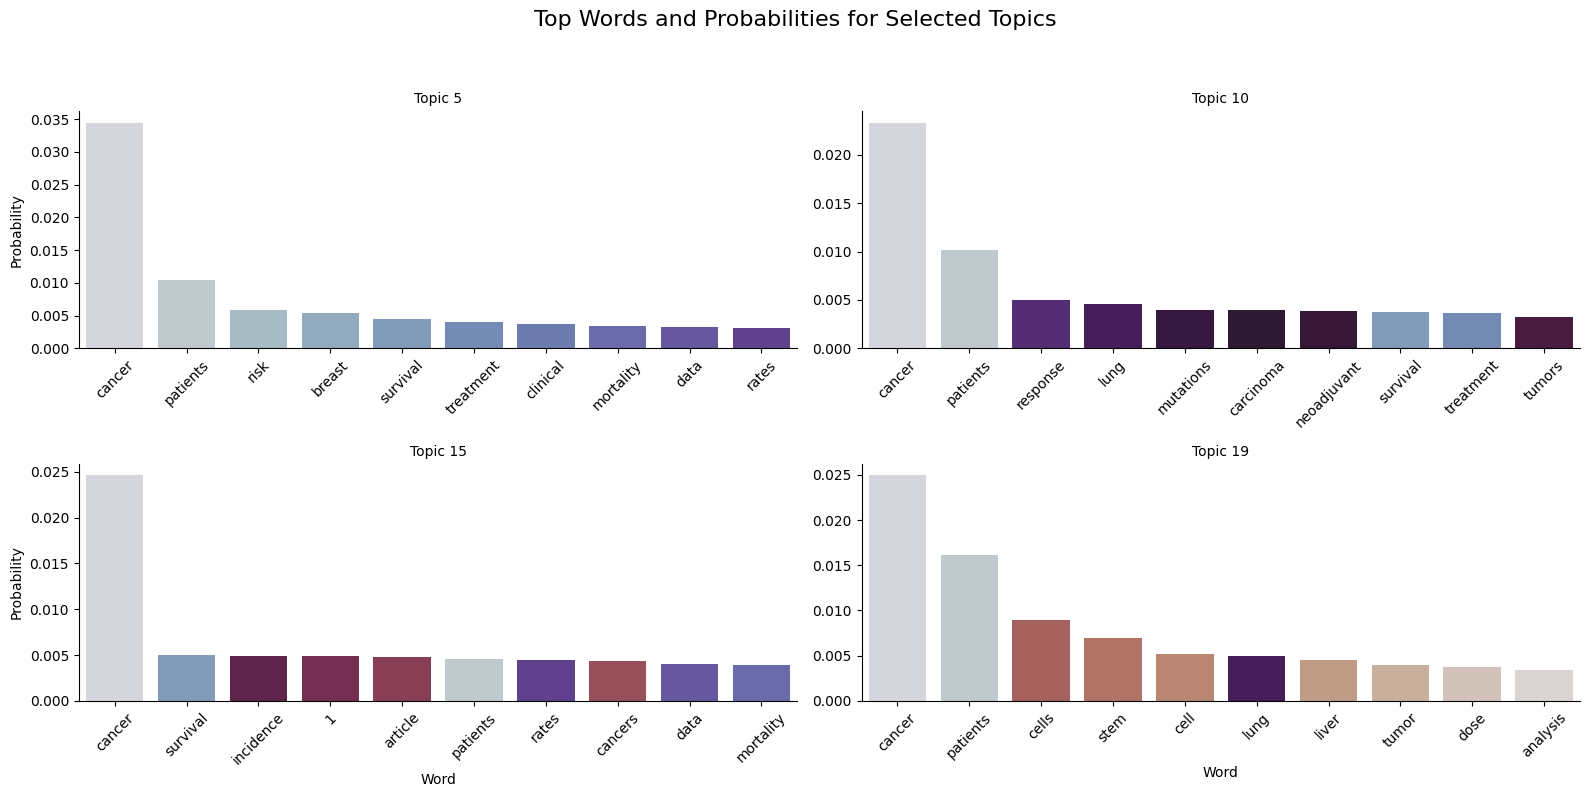

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.catplot(data=df_topic_words, x='Word', y='Probability', col='Topic ID', col_wrap=2, kind='bar',
                height=4, aspect=2, hue='Word', legend=False, palette='twilight', sharex=False, sharey=False)

g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Top Words and Probabilities for Selected Topics', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Interactive Visualization

In [63]:
vis = pyLDAvis.gensim_models.prepare(lda_model_10, corpus, id2word, mds="mmds", R=30)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4     -0.087149  0.023041       1        1  28.486378
3      0.019892  0.039748       2        1  13.429039
2     -0.073426  0.069228       3        1  10.091297
5      0.030018 -0.014957       4        1   9.840845
9      0.077245 -0.038459       5        1   9.824159
6      0.077851  0.037164       6        1   7.502142
7      0.007371  0.075077       7        1   6.359252
0      0.022290 -0.076776       8        1   6.126028
8     -0.041301 -0.094939       9        1   4.472580
1     -0.032792 -0.019127      10        1   3.868280, topic_info=         Term         Freq        Total Category  logprob  loglift
4      cancer  2533.000000  2533.000000  Default  30.0000  30.0000
82   patients   498.000000   498.000000  Default  29.0000  29.0000
140       fig    79.000000    79.000000  Default  28.0000  28.0000
552     cells   173.000000   173.000000  Default  27.0000  27.0000
130   article   105.000000   105.000000  Default  26.0000  26.0000
..        ...          ...          ...      ...      ...      ...
130   article     4.205606   105.633971  Topic10  -6.2012   0.0288
124         1     4.302358   116.473680  Topic10  -6.1784  -0.0461
120    tumors     4.008955    95.143339  Topic10  -6.2490   0.0855
289   primary     3.753500    84.076581  Topic10  -6.3149   0.1433
384  response     3.606684    82.370795  Topic10  -6.3548   0.1239

[826 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
124       1  0.188884             1
124       2  0.077271             1
124       3  0.085856             1
124       4  0.111613             1
124       5  0.248983             1
...     ...       ...           ...
850      10  0.021823         years
6834      8  0.464161  zanubrutinib
9915     10  0.796635  zolbetuximab
6627      3  0.608565         “full
6628      3  0.611802  “references”

[2275 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 4, 3, 6, 10, 7, 8, 1, 9, 2])

TASK 5

What went well?

Loading the dataset, preprocessing, and running LDA models was a breeze.Encountered 0 issues.

What did not go well or what challenges you encountered?

Many abstracts (descriptions) were short or contained many generic terms. I had to add additional custom stopwords.

In what ways could topic modeling be integrated into your current or future professional or research work?

I believe it is a useful way discover hidden themes/topics in large collections of documents, mainly for organizing digital collections.





